In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings

warnings.filterwarnings('ignore')

**Link Video**:
https://drive.google.com/file/d/19a-Z4P7Vr_3r9uDjnT-fdoMuJuNy5Fjm/view?usp=sharing

**Link Streamlit**:
https://final-app-deloy---jonathan-oritupt8rzbzi27v3tvbum.streamlit.app/

# Loading & Initial Discovery

In [22]:
# Load dataset C
df = pd.read_csv('data_C.csv')

pd.set_option('display.max_columns', None)
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,6,8,32,3,"Personal Loan, Student Loan, and Mortgage Loan",23,9,10.3,11.0,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897591535379,High_spent_Small_value_payments,303.917665,Standard
1,1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.571667,9,10,1663,2,"Personal Loan, and Student Loan",58,14,15.53,6.0,Standard,2149.9,23.451285,NaN,Yes,11.564437,54.46174813453877,Low_spent_Medium_value_payments,309.130981,Poor
2,2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.070000,1,6,2,1,Auto Loan,25,4,5.04,1.0,Good,387.53,31.100297,24 Years and 3 Months,No,98.031931,478.3574716999517,High_spent_Small_value_payments,920.817597,Standard
3,3,0x8ac9,CUS_0x5534,April,Aubinr,39,246-34-3138,Developer,23200.82,NaN,3,7,5,0,NaN,30,15,24.73,6.0,Standard,987.07,26.786925,17 Years and 7 Months,Yes,0.000000,65.84983488267585,Low_spent_Large_value_payments,391.890332,Standard
4,4,0x24a41,CUS_0x104f,April,Markm,20,264-84-8069,Architect,11336.835,992.736250,4,1405,14,6,"Auto Loan, Payday Loan, Student Loan, Auto Loa...",30,19,16.44,7.0,Standard,177.98,24.001752,14 Years and 7 Months,Yes,35.562731,NaN,Low_spent_Small_value_payments,228.245999,Standard


In [23]:
# Dimensi
print(f"Baris: {df.shape[0]} \nKolom: {df.shape[1]}")

# Cek tipe data
df.info()

Baris: 25000 
Kolom: 29
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22570 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21164 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-n

In [24]:
# Check missing
df.isna().sum()

Unnamed: 0                     0
ID                             0
Customer_ID                    0
Month                          0
Name                        2430
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       3836
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                2852
Delay_from_due_date            0
Num_of_Delayed_Payment      1792
Changed_Credit_Limit           0
Num_Credit_Inquiries         472
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          2240
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     1134
Payment_Behaviour              0
Monthly_Balance              301
Credit_Score                   0
dtype: int64

In [25]:
# Check duplikat
df.duplicated().sum()

0

In [26]:
# Check value counts dari kolom target kategorikal
print(df['Credit_Score'].value_counts())


Credit_Score
Standard    13282
Poor         7268
Good         4450
Name: count, dtype: int64


In [27]:
# Cek nilai unik kolom categorical untuk deteksi nilai kotor
cat_cols = ['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 
            'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_History_Age']

for col in cat_cols:
    print(f"----- '{col}' -----")
    print(df[col].unique()[:20])
    print()

----- 'Month' -----
['August' 'June' 'April' 'July' 'February' 'May' 'January' 'March']

----- 'Occupation' -----
['Journalist' 'Teacher' '_______' 'Developer' 'Architect' 'Doctor'
 'Media_Manager' 'Accountant' 'Entrepreneur' 'Lawyer' 'Writer' 'Engineer'
 'Manager' 'Musician' 'Scientist' 'Mechanic']

----- 'Type_of_Loan' -----
['Personal Loan, Student Loan, and Mortgage Loan'
 'Personal Loan, and Student Loan' 'Auto Loan' nan
 'Auto Loan, Payday Loan, Student Loan, Auto Loan, Auto Loan, and Personal Loan'
 'Personal Loan, Auto Loan, Credit-Builder Loan, Auto Loan, Payday Loan, Payday Loan, and Home Equity Loan'
 'Mortgage Loan, Payday Loan, and Credit-Builder Loan'
 'Mortgage Loan, and Student Loan'
 'Personal Loan, Home Equity Loan, and Student Loan'
 'Student Loan, Mortgage Loan, and Student Loan'
 'Payday Loan, Debt Consolidation Loan, Debt Consolidation Loan, and Credit-Builder Loan'
 'Not Specified, Personal Loan, Not Specified, Home Equity Loan, Personal Loan, Payday Loan, and Cr

In [28]:
# Cek kolom yang harusnya numerik tapi dtype-nya object
# Mungkin ada nilai kotor di dalamnya
numeric_as_object = ['Age', 'Annual_Income', 'Num_of_Loan', 
                     'Changed_Credit_Limit', 'Num_of_Delayed_Payment',
                     'Outstanding_Debt', 'Amount_invested_monthly']

print("\nKOLOM NUMERIK YANG TERSIMPAN SEBAGAI OBJECT")
for col in numeric_as_object:
    print(f"----- '{col}' -----")
    print(df[col].unique()[:10])
    print()


KOLOM NUMERIK YANG TERSIMPAN SEBAGAI OBJECT
----- 'Age' -----
['35' '46' '19' '39' '20' '34' '24' '45' '22' '28']

----- 'Annual_Income' -----
['20364.57' '9786.86' '146880.84' '23200.82' '11336.835' '8922.155'
 '20487.905' '54265.54' '101114.73' '63306.54']

----- 'Num_of_Loan' -----
['3' '2' '1' '0' '6' '7' '4' '8' '0_' '-100']

----- 'Changed_Credit_Limit' -----
['10.3' '15.53' '5.04' '24.73' '16.44' '18.61' '6.05' '4.78' '24.91'
 '8.09']

----- 'Num_of_Delayed_Payment' -----
['9' '14' '4' '15' '19' nan '13' '11' '10' '8']

----- 'Outstanding_Debt' -----
['2500.04' '2149.9' '387.53' '987.07' '177.98' '4648.32' '1464.77'
 '545.37' '1190.45' '1203.19']

----- 'Amount_invested_monthly' -----
['92.51897591535379' '54.46174813453877' '478.3574716999517'
 '65.84983488267585' nan '102.11048074801573' '64.78254782421534'
 '396.4845290738466' '116.52344476791184' '120.0391513715411']



In [29]:
# Statistik deskriptif (hanya kolom numerik beneran)
df.describe()

,Unnamed: 0,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month,Monthly_Balance
count,25000.000000,21164.000000,25000.000000,25000.000000,25000.000000,25000.000000,24528.000000,25000.000000,25000.000000,24699.000000
mean,12499.500000,4189.505970,18.075360,22.238000,75.407480,20.988400,28.449976,32.277257,1465.714590,403.454486
std,7217.022701,3208.575501,122.375374,126.156225,478.786499,14.851345,197.078633,5.126823,8514.582351,215.613056
min,0.000000,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.100770,0.000000,0.088628
25%,6249.750000,1611.188333,3.000000,4.000000,8.000000,10.000000,3.000000,28.043382,30.181528,269.935928
50%,12499.500000,3071.424583,6.000000,5.000000,14.000000,18.000000,6.000000,32.309314,68.248891,335.519841
75%,18749.250000,5941.093333,7.000000,7.000000,20.000000,28.000000,9.000000,36.488060,159.990097,472.202042
max,24999.000000,15204.633333,1789.000000,1498.000000,5797.000000,67.000000,2592.000000,50.000000,82331.000000,1564.134826


### Hasil Loading Data

Dataset terdiri dari 25.000 baris dan 29 kolom. Tidak ada duplikat.

| Temuan | Detail |
| :--- | :--- |
| **Kolom yang Akan Di-drop** | `Unnamed: 0` (index), `ID`, `Customer_ID`, `SSN`, `Name` karena ini adalah identifier, tidak ada nilai prediktif |
| **Missing Values** | `Monthly_Inhand_Salary` (3836), `Type_of_Loan` (2852), `Credit_History_Age` (2240), `Num_of_Delayed_Payment` (1792), `Amount_invested_monthly` (1134), `Num_Credit_Inquiries` (472), `Monthly_Balance` (301) |
| **Nilai Kotor Kategorikal** | `_______` di Occupation, `_` di Credit_Mix, `NM` di Payment_of_Min_Amount, `!@9#%8` di Payment_Behaviour |
| **Kolom Numerik Tersimpan sebagai Object** | `Age`, `Annual_Income`, `Num_of_Loan`, `Changed_Credit_Limit`, `Num_of_Delayed_Payment`, `Outstanding_Debt`, `Amount_invested_monthly` |
| **Nilai Tidak Masuk Akal** | `Num_of_Loan` ada `0_` dan `-100`, `Interest_Rate` max 5797, `Num_Bank_Accounts` min -1, `Delay_from_due_date` min -5, `Num_Bank_Accounts` max 1789, `Num_Credit_Card` max 1498, `Num_Credit_Inquiries` max 2592 |
| **Kolom Perlu Konversi** | `Credit_History_Age` → total bulan, `Type_of_Loan` → butuh strategi encoding tersendiri |
| **Target (Credit_Score)** | Tidak balanced: Standard 13282, Poor 7268, Good 4450 |

# Initial Cleaning

In [30]:
# Drop kolom yang tidak memiliki nilai prediktif
cols_to_drop = ['Unnamed: 0', 'ID', 'Customer_ID', 'SSN', 'Name']
df = df.drop(columns=cols_to_drop, errors='ignore')

print("Sisa kolom:", df.shape[1])

Sisa kolom: 24


In [31]:
# Ganti string kotor dengan NaN 
dirty_values = ['_______', '_', 'NM', '!@9#%8']
df = df.replace(dirty_values, np.nan)

# Cek hasil perubahan di beberapa kolom terkait
print("Jumlah NaN setelah replace:")
print(df[['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']].isna().sum())

Jumlah NaN setelah replace:
Occupation               1765
Credit_Mix               4926
Payment_of_Min_Amount    2947
Payment_Behaviour        1951
dtype: int64


In [32]:
# Kolom yang seharusnya numerik tapi terbaca object/string karena ada karakter aneh
num_obj_cols = ['Age', 'Annual_Income', 'Num_of_Loan', 'Changed_Credit_Limit', 
                'Num_of_Delayed_Payment', 'Outstanding_Debt', 'Amount_invested_monthly']

for col in num_obj_cols:
    if df[col].dtype == 'object':
        # Hapus semua karakter selain angka, minus (-), dan titik desimal (.)
        df[col] = df[col].astype(str).str.replace(r'[^\d.-]', '', regex=True)
        
        # Ubah string kosong sisa regex menjadi NaN, lalu convert ke float
        df[col] = df[col].replace('', np.nan).astype(float)

print("Tipe data setelah konversi:")
print(df[num_obj_cols].dtypes)

Tipe data setelah konversi:
Age                        float64
Annual_Income              float64
Num_of_Loan                float64
Changed_Credit_Limit       float64
Num_of_Delayed_Payment     float64
Outstanding_Debt           float64
Amount_invested_monthly    float64
dtype: object


In [33]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,25000.000000,2.500000e+04,21164.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,23208.000000,24482.000000,24528.000000,25000.000000,25000.000000,25000.000000,23866.000000,24699.000000
mean,108.102760,1.623404e+05,4189.505970,18.075360,22.238000,75.407480,3.118400,20.988400,30.123233,10.392018,28.449976,1429.101565,32.277257,1465.714590,626.051602,403.454486
std,670.342409,1.343255e+06,3208.575501,122.375374,126.156225,478.786499,62.976089,14.851345,220.647502,6.812396,197.078633,1159.002177,5.126823,8514.582351,2019.456383,215.613056
min,-500.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,-100.000000,-5.000000,-3.000000,-6.480000,0.000000,0.340000,20.100770,0.000000,0.000000,0.088628
25%,24.000000,1.920549e+04,1611.188333,3.000000,4.000000,8.000000,1.000000,10.000000,9.000000,5.300000,3.000000,568.810000,28.043382,30.181528,73.951929,269.935928
50%,33.000000,3.731332e+04,3071.424583,6.000000,5.000000,14.000000,3.000000,18.000000,14.000000,9.440000,6.000000,1163.435000,32.309314,68.248891,134.361493,335.519841
75%,42.000000,7.271220e+04,5941.093333,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.910000,9.000000,1953.002500,36.488060,159.990097,265.304048,472.202042
max,8697.000000,2.416001e+07,15204.633333,1789.000000,1498.000000,5797.000000,1495.000000,67.000000,4384.000000,35.820000,2592.000000,4997.100000,50.000000,82331.000000,10000.000000,1564.134826


### Temuan Tambahan Setelah Konversi Tipe Data

Setelah `Age`, `Num_of_Loan`, dan `Num_of_Delayed_Payment` dikonversi ke numerik, `describe()` ulang menunjukkan beberapa kolom count/diskrit lain dengan nilai min/max yang tidak masuk akal secara logis (bukan sekadar outlier statistik):

| Kolom | Min | Max | Catatan |
| :--- | ---: | ---: | :--- |
| `Age` | -500 | 8697 | min sudah tertangkap `cols_with_invalid_negatives`, max baru |
| `Num_Bank_Accounts` | -1 | 1789 | min sudah tertangkap, max baru |
| `Num_Credit_Card` | 0 | 1498 | min aman, max baru |
| `Num_of_Loan` | -100 | 1495 | min sudah tertangkap, max baru |
| `Num_of_Delayed_Payment` | -3 | 4384 | min **dan** max baru, belum ada di `cols_with_invalid_negatives` |
| `Num_Credit_Inquiries` | 0 | 2592 | min aman, max baru |

Keenam kolom ini akan diperlakukan sebagai missing value (NaN → median impute), bukan di-cap seperti `Interest_Rate`, karena nilai aslinya sudah tidak menyisakan informasi yang bisa dipercaya.

In [34]:
# Mengubah nilai yang tidak mungkin negatif menjadi NaN
cols_with_invalid_negatives = ['Num_of_Loan', 'Num_Bank_Accounts', 'Delay_from_due_date', 'Age', 'Num_of_Delayed_Payment']

for col in cols_with_invalid_negatives:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan

print("Nilai minimum setelah dibersihkan (seharusnya >= 0):")
print(df[['Num_of_Loan', 'Num_Bank_Accounts', 'Delay_from_due_date', 'Age', 'Num_of_Delayed_Payment']].describe().loc['min'])

Nilai minimum setelah dibersihkan (seharusnya >= 0):
Num_of_Loan                0.0
Num_Bank_Accounts          0.0
Delay_from_due_date        0.0
Age                       14.0
Num_of_Delayed_Payment     0.0
Name: min, dtype: float64


In [35]:
# Ekstrak angka tahun ke kolom 0 dan angka bulan ke kolom 1
ekstrak = df['Credit_History_Age'].str.extract(r'(\d+) Years and (\d+) Months')

# tahun kali 12 + bulan
df['Credit_History_Age'] = (ekstrak[0].astype(float) * 12) + ekstrak[1].astype(float)

print("5 baris pertama Credit_History_Age (dalam format bulan):")
print(df['Credit_History_Age'].head())

5 baris pertama Credit_History_Age (dalam format bulan):
0    116.0
1      NaN
2    291.0
3    211.0
4    175.0
Name: Credit_History_Age, dtype: float64


In [36]:
# Cap Interest_Rate di 100 nilai di atas itu tidak realistis
df['Interest_Rate'] = df['Interest_Rate'].clip(upper=100)

print(f"Max Interest_Rate setelah capping: {df['Interest_Rate'].max()}")
print(f"Jumlah nilai yang di-cap: {(df['Interest_Rate'] == 100).sum()}")

Max Interest_Rate setelah capping: 100
Jumlah nilai yang di-cap: 530


In [37]:
# Mengubah nilai max yang tidak realistis menjadi NaN (akan diimpute, bukan di-cap seperti Interest_Rate)
cols_with_invalid_max = {
    'Age': 100,
    'Num_Bank_Accounts': 20,
    'Num_Credit_Card': 20,
    'Num_of_Loan': 15,
    'Num_of_Delayed_Payment': 30,
    'Num_Credit_Inquiries': 20,
}

for col, threshold in cols_with_invalid_max.items():
    df.loc[df[col] > threshold, col] = np.nan

print("Nilai maximum setelah dibersihkan:")
print(df[list(cols_with_invalid_max.keys())].describe().loc['max'])

Nilai maximum setelah dibersihkan:
Age                       95.0
Num_Bank_Accounts         18.0
Num_Credit_Card           18.0
Num_of_Loan                9.0
Num_of_Delayed_Payment    28.0
Num_Credit_Inquiries      17.0
Name: max, dtype: float64


### Encoding Type_of_Loan

`Type_of_Loan` isinya multi-value: satu nasabah bisa punya beberapa jenis pinjaman sekaligus, dipisah koma, dan banyak duplikat plus nilai "Not Specified". Kalau di-OHE utuh, kombinasinya ratusan dan kolomnya meledak.

Solusinya multi-hot. Jenis pinjaman individu yang muncul di data ada 9 (Auto, Credit-Builder, Debt Consolidation, Home Equity, Mortgage, Payday, Personal, Student, dan Not Specified). "Not Specified" dianggap missing, jadi dibuat 8 kolom biner. Tiap kolom bernilai 1 kalau nasabah punya jenis pinjaman itu, 0 kalau tidak. Baris yang NaN otomatis 0 di semua kolom.

In [38]:
mask = df['Type_of_Loan'].isna()
print(df.loc[mask, 'Num_of_Loan'].value_counts(dropna=False))

Num_of_Loan
0.0    2717
NaN     135
Name: count, dtype: int64


NaN di Type_of_Loan otomatis jadi 0 di semua kolom multi-hot. Awalnya saya pertimbangkan impute top-N jenis pinjaman berdasarkan Num_of_Loan, tapi setelah ditelusuri (lihat value counts di atas), baris yang Type_of_Loan-nya kosong cuma ada di dua kondisi: nasabah tidak punya pinjaman (Num_of_Loan = 0) atau Num_of_Loan-nya sudah NaN dari cleaning sebelumnya. Tidak ada baris dengan pinjaman valid tapi jenisnya kosong, jadi strategi top-N tidak applicable dan all-zero tetap paling konsisten.



In [39]:
# Multi-hot Type_of_Loan: pecah jadi 8 kolom biner per jenis pinjaman
# "Not Specified" di-ignore
loan_types = ['Auto Loan', 'Credit-Builder Loan', 'Debt Consolidation Loan',
              'Home Equity Loan', 'Mortgage Loan', 'Payday Loan',
              'Personal Loan', 'Student Loan']

for loan in loan_types:
    col = loan.replace(' ', '_').replace('-', '_')
    df[col] = df['Type_of_Loan'].fillna('').str.contains(loan, regex=False).astype('int64')

# Drop kolom asli yang sudah dipecah
df = df.drop(columns=['Type_of_Loan'])

print("Kolom biner yang dibuat:")
print(df[[l.replace(' ', '_').replace('-', '_') for l in loan_types]].sum())

Kolom biner yang dibuat:
Auto_Loan                  7647
Credit_Builder_Loan        7901
Debt_Consolidation_Loan    7778
Home_Equity_Loan           7797
Mortgage_Loan              7821
Payday_Loan                8053
Personal_Loan              7854
Student_Loan               7783
dtype: int64


# Splitting

In [40]:
from sklearn.model_selection import train_test_split

# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=['Credit_Score'])
y = df['Credit_Score']

# Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Latih: {X_train.shape}")
print(f"Jumlah Data Uji: {X_test.shape}")

Jumlah Data Latih: (20000, 30)
Jumlah Data Uji: (5000, 30)


# Visualisasi Data

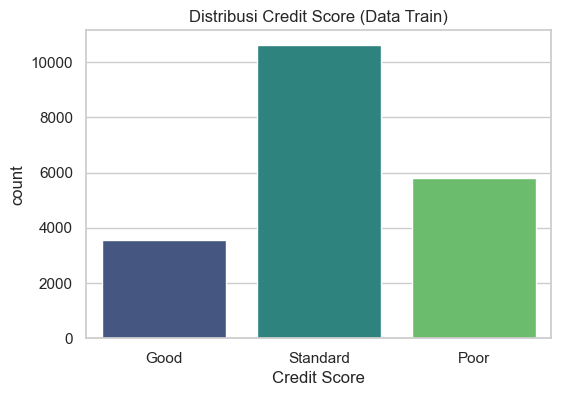

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette='viridis', order=['Good', 'Standard', 'Poor'])
plt.title('Distribusi Credit Score (Data Train)')
plt.xlabel('Credit Score')
plt.show()

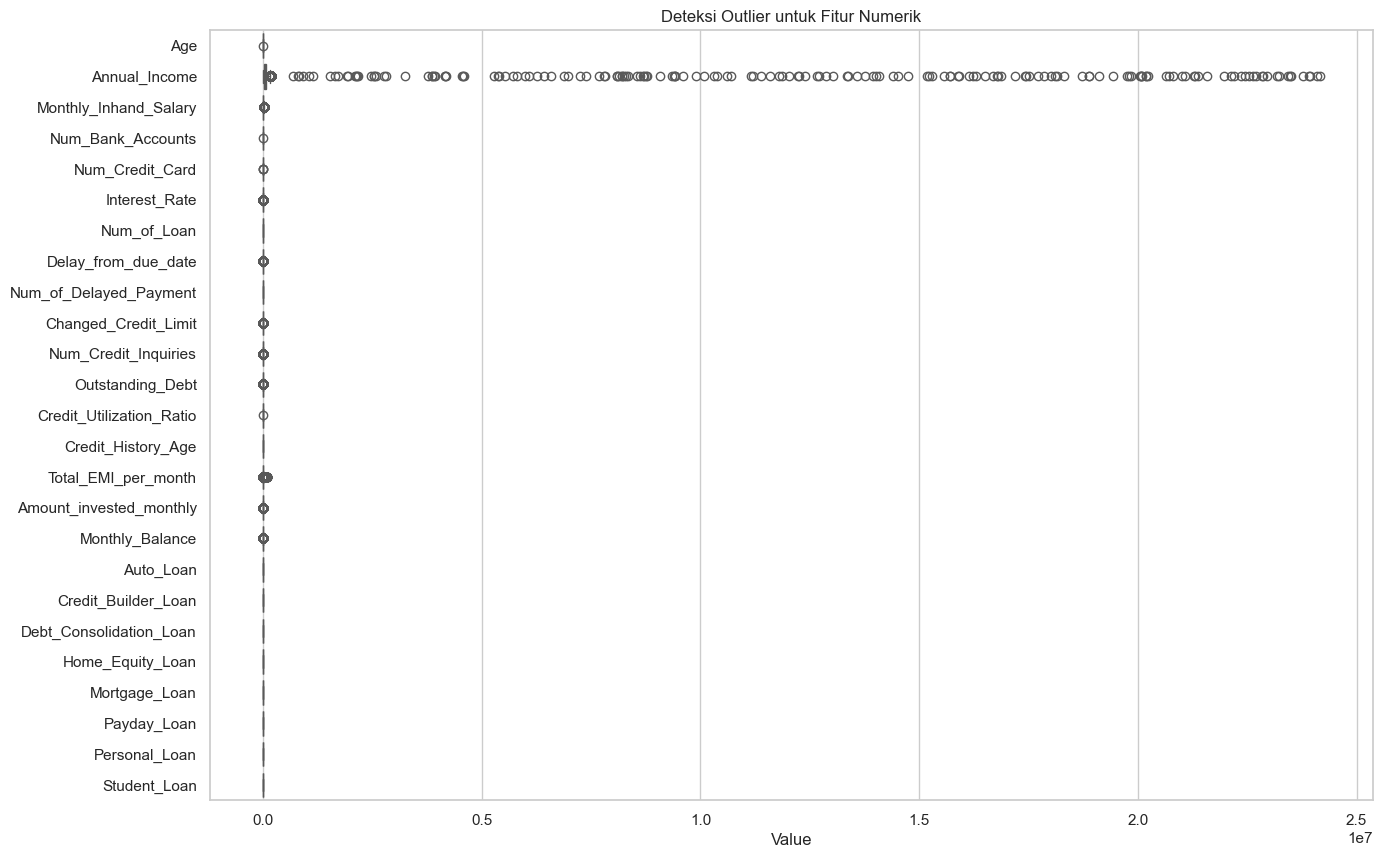

In [42]:
# Ambil kolom numerik dari X_train
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 10))
sns.boxplot(data=X_train[num_cols], orient="h", palette="Set2")
plt.title("Deteksi Outlier untuk Fitur Numerik")
plt.xlabel("Value")
plt.show()

In [43]:
print("Outlier Percentage for Each Column:")
for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]
    percentage = (len(outliers) / len(X_train)) * 100
    
    print(f"{col:25} : {percentage:.2f}% ({len(outliers)} outliers)")

Outlier Percentage for Each Column:
Age                       : 0.01% (1 outliers)
Annual_Income             : 2.88% (575 outliers)
Monthly_Inhand_Salary     : 1.85% (371 outliers)
Num_Bank_Accounts         : 0.01% (1 outliers)
Num_Credit_Card           : 0.01% (3 outliers)
Interest_Rate             : 2.10% (421 outliers)
Num_of_Loan               : 0.00% (0 outliers)
Delay_from_due_date       : 3.88% (776 outliers)
Num_of_Delayed_Payment    : 0.00% (0 outliers)
Changed_Credit_Limit      : 0.60% (120 outliers)
Num_Credit_Inquiries      : 0.76% (151 outliers)
Outstanding_Debt          : 5.31% (1062 outliers)
Credit_Utilization_Ratio  : 0.01% (1 outliers)
Credit_History_Age        : 0.00% (0 outliers)
Total_EMI_per_month       : 7.07% (1413 outliers)
Amount_invested_monthly   : 9.95% (1989 outliers)
Monthly_Balance           : 7.72% (1544 outliers)
Auto_Loan                 : 0.00% (0 outliers)
Credit_Builder_Loan       : 0.00% (0 outliers)
Debt_Consolidation_Loan   : 0.00% (0 outliers)


In [44]:
# 1. Petakan target ke bentuk numerik ordinal (sementara untuk analisis korelasi)
score_mapping = {'Poor': 0, 'Standard': 1, 'Good': 2}
y_train_num = y_train.map(score_mapping)

# 2. Ambil hanya kolom numerik dari X_train
train_num = X_train.select_dtypes(include=['float64', 'int64']).copy()

# 3. Gabungkan dengan target numerik
train_full = pd.concat([train_num, y_train_num.rename('Credit_Score_Num')], axis=1)

# 4. Hitung korelasi terhadap target
correlations = train_full.corr()
target_corrs = correlations[['Credit_Score_Num']].sort_values(by='Credit_Score_Num', ascending=False)

print("Korelasi Fitur Numerik terhadap Credit Score (0: Poor, 1: Standard, 2: Good):")
print(target_corrs)

Korelasi Fitur Numerik terhadap Credit Score (0: Poor, 1: Standard, 2: Good):
                          Credit_Score_Num
Credit_Score_Num                  1.000000
Credit_History_Age                0.388289
Monthly_Inhand_Salary             0.221205
Monthly_Balance                   0.218777
Age                               0.153557
Credit_Utilization_Ratio          0.051832
Annual_Income                     0.011733
Total_EMI_per_month               0.007031
Amount_invested_monthly           0.002863
Student_Loan                     -0.131903
Home_Equity_Loan                 -0.137345
Debt_Consolidation_Loan          -0.143050
Auto_Loan                        -0.144667
Personal_Loan                    -0.146602
Credit_Builder_Loan              -0.146670
Payday_Loan                      -0.147610
Mortgage_Loan                    -0.147695
Changed_Credit_Limit             -0.183408
Interest_Rate                    -0.278791
Num_of_Loan                      -0.356983
Num_of_Delayed_Paym

In [45]:
X_train.shape

(20000, 30)

### Temuan Analitis dari Visualisasi Data

**1. Distribusi Credit Score**
Target tidak seimbang: Standard (~10.500), Poor (~5.800), Good (~3.500).
Perlu diperhatikan saat pemilihan metrik evaluasi model.

**2. Deteksi Outlier**
`Annual_Income` memiliki outlier ekstrem (terlihat di plot) sehingga mendominasi skala plot.
Kolom dengan outlier terbanyak: `Amount_invested_monthly` (9.95%), `Monthly_Balance` (7.72%),
`Total_EMI_per_month` (7.07%). Outlier tidak dihapus karena model berbasis pohon robust terhadap nilai ekstrem.

**3. Analisis Korelasi**
Prediktor terkuat:
- `Delay_from_due_date` (-0.432) dan `Outstanding_Debt` (-0.390) berkorelasi negatif paling kuat
- `Credit_History_Age` (+0.388) menjadi satu-satunya fitur positif yang signifikan
- `Monthly_Inhand_Salary` (+0.221) dan `Monthly_Balance` (+0.219) juga menunjukkan pengaruh positif
- 8 kolom pinjaman hasil multi-hot berada di kisaran -0.13 sampai -0.15, lebih kuat dari beberapa fitur numerik seperti `Age` dan `Num_of_Loan`. Nasabah yang punya pinjaman cenderung punya credit score lebih rendah.

Fitur seperti `Age` dan `Num_Credit_Card` mendekati 0 secara linear, namun tetap dipertahankan untuk model non-linear.

# Feature Engineering & Model Pipeline Construction

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Definisi fitur
num_features = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
ordinal_features = ['Credit_Mix']  # Bad < Standard < Good
cat_features = [c for c in X_train.select_dtypes(include=['object']).columns.tolist()
                if c not in ordinal_features]

# Pipeline numerik: median (robust terhadap outlier) + scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline ordinal: Credit_Mix punya urutan natural
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['Bad', 'Standard', 'Good']]))
])

# Pipeline kategorikal nominal
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Gabung
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

print("Fitur Numerik:", num_features)
print("Fitur Ordinal:", ordinal_features)
print("Fitur Kategorikal:", cat_features)

Fitur Numerik: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Auto_Loan', 'Credit_Builder_Loan', 'Debt_Consolidation_Loan', 'Home_Equity_Loan', 'Mortgage_Loan', 'Payday_Loan', 'Personal_Loan', 'Student_Loan']
Fitur Ordinal: ['Credit_Mix']
Fitur Kategorikal: ['Month', 'Occupation', 'Payment_of_Min_Amount', 'Payment_Behaviour']


### Alasan Pemilihan Preprocessing

1. **SimpleImputer**
   Median dipilih untuk numerik, bukan mean, karena dataset memiliki outlier ekstrem
   (contoh: `Annual_Income`) yang akan menarik mean jauh dari nilai tipikal.
   Most_frequent untuk kategorikal karena tidak ada nilai "netral" seperti pada numerik.

2. **OrdinalEncoder (khusus `Credit_Mix`)**
   `Credit_Mix` memiliki urutan natural Bad < Standard < Good, sehingga OrdinalEncoder
   lebih tepat daripada OHE yang akan memperlakukan ketiga kategori seolah setara
   dan membuang informasi urutan tersebut.

3. **OneHotEncoder (fitur kategorikal nominal)**
   `Month`, `Occupation`, `Payment_of_Min_Amount`, `Payment_Behaviour` tidak memiliki
   urutan, sehingga OrdinalEncoder tidak sesuai karena akan menghasilkan urutan arbitrer
   yang menyesatkan model linear. `handle_unknown='ignore'` ditambahkan agar pipeline
   tidak error saat menerima kategori baru dari input Streamlit.

4. **StandardScaler**
   Dipilih karena tidak terikat pada rentang nilai tertentu seperti MinMaxScaler
   yang rentan terhadap outlier. Terutama dibutuhkan untuk model linear seperti
   Logistic Regression agar fitur berskala besar tidak mendominasi.

### Train dan Bandingkan 10 Model

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier,
                               BaggingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier

# 10 model yang akan dicoba
models = [
    ("Logistic_Regression", LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ("Decision_Tree", DecisionTreeClassifier(class_weight='balanced', random_state=42)),
    ("Random_Forest", RandomForestClassifier(class_weight='balanced', random_state=42)),
    ("Extra_Trees", ExtraTreesClassifier(class_weight='balanced', random_state=42)),
    ("Gradient_Boosting", GradientBoostingClassifier(random_state=42)),
    ("Hist_Gradient_Boosting", HistGradientBoostingClassifier(random_state=42)),
    ("AdaBoost", AdaBoostClassifier(random_state=42)),
    ("Bagging", BaggingClassifier(random_state=42)),
    ("SVC", SVC(class_weight='balanced', probability=True, random_state=42)),
    ("KNeighbors", KNeighborsClassifier()),
]

# List untuk menampung hasil
performance_results = []

for model_name, model_obj in models:
    # Build Pipeline
    current_pipeline = Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('classifier', model_obj)
    ])
    
    # Training 
    current_pipeline.fit(X_train, y_train)
    
    # Prediksi label dan probabilitas 
    y_pred = current_pipeline.predict(X_test)
    y_proba = current_pipeline.predict_proba(X_test)
    
    # Hitung 3 Metrik Evaluasi
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    
    # Simpan hasil ke list
    performance_results.append({
        "Model": model_name,
        "Accuracy": acc,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "Pipeline": current_pipeline
    })
    
    print(f"{model_name} Selesai.")
    print(f"Accuracy  : {acc:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}\n")

# Urutkan berdasarkan F1-Score, ambil top 3
sorted_results = sorted(performance_results, key=lambda x: x['F1-Score'], reverse=True)
top3 = sorted_results[:3]

print("TOP 3 MODEL BERDASARKAN F1-SCORE")
for i, entry in enumerate(top3, 1):
    print(f"{i}. {entry['Model']}")
    print(f"   Accuracy : {entry['Accuracy']:.4f}")
    print(f"   F1-Score : {entry['F1-Score']:.4f}")
    print(f"   ROC-AUC  : {entry['ROC-AUC']:.4f}")
    print()

best_model_entry = top3[0]
print(f"Model terbaik: {best_model_entry['Model']} (F1 = {best_model_entry['F1-Score']:.4f})")

Logistic_Regression Selesai.
Accuracy  : 0.6354
F1-Score  : 0.6388
ROC-AUC   : 0.7767

Decision_Tree Selesai.
Accuracy  : 0.6398
F1-Score  : 0.6394
ROC-AUC   : 0.6936

Random_Forest Selesai.
Accuracy  : 0.7364
F1-Score  : 0.7356
ROC-AUC   : 0.8614

Extra_Trees Selesai.
Accuracy  : 0.7226
F1-Score  : 0.7218
ROC-AUC   : 0.8564

Gradient_Boosting Selesai.
Accuracy  : 0.6996
F1-Score  : 0.6993
ROC-AUC   : 0.8349

Hist_Gradient_Boosting Selesai.
Accuracy  : 0.7122
F1-Score  : 0.7120
ROC-AUC   : 0.8512

AdaBoost Selesai.
Accuracy  : 0.6542
F1-Score  : 0.6523
ROC-AUC   : 0.7334

Bagging Selesai.
Accuracy  : 0.6986
F1-Score  : 0.6998
ROC-AUC   : 0.8268

SVC Selesai.
Accuracy  : 0.6724
F1-Score  : 0.6758
ROC-AUC   : 0.8165

KNeighbors Selesai.
Accuracy  : 0.6586
F1-Score  : 0.6577
ROC-AUC   : 0.7843

TOP 3 MODEL BERDASARKAN F1-SCORE
1. Random_Forest
   Accuracy : 0.7364
   F1-Score : 0.7356
   ROC-AUC  : 0.8614

2. Extra_Trees
   Accuracy : 0.7226
   F1-Score : 0.7218
   ROC-AUC  : 0.8564

3. H

Random Forest unggul di semua metrik utama dengan F1-Score 0.7356 dan ROC-AUC 0.8614, diikuti Extra Trees (F1: 0.7218) dan Hist Gradient Boosting (F1: 0.7120) di posisi kedua dan ketiga. Model linear seperti Logistic Regression dan SVC tertinggal cukup jauh, mengindikasikan hubungan antar fitur dalam dataset ini bersifat non-linear. Decision Tree meski cepat, performanya lebih rendah karena rentan overfitting tanpa mekanisme ensemble. Random Forest dipilih sebagai model terbaik untuk dilanjutkan ke tahap hyperparameter tuning.

In [48]:
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone

tuning_pipe = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [20, None],          
    'classifier__min_samples_leaf': [6, 1] 
}

grid_search = GridSearchCV(tuning_pipe, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("--- HASIL TUNING ---")
print(f"Best F1-Score: {grid_search.best_score_:.4f}")
print(f"Best Params  : {grid_search.best_params_}")

best_pipeline = grid_search.best_estimator_

--- HASIL TUNING ---
Best F1-Score: 0.7150
Best Params  : {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 150}


In [49]:
from sklearn.metrics import classification_report

y_pred_final = best_pipeline.predict(X_test)

print("FINAL MODEL CLASSIFICATION REPORT (TUNED)")
print(classification_report(y_test, y_pred_final,
                             labels=['Good', 'Standard', 'Poor'],
                             target_names=['Good', 'Standard', 'Poor']))

FINAL MODEL CLASSIFICATION REPORT (TUNED)
              precision    recall  f1-score   support

        Good       0.59      0.74      0.65       890
    Standard       0.79      0.72      0.76      2656
        Poor       0.73      0.73      0.73      1454

    accuracy                           0.73      5000
   macro avg       0.70      0.73      0.71      5000
weighted avg       0.74      0.73      0.73      5000



Setelah hyperparameter tuning dengan GridSearchCV (membandingkan `max_depth` dan `min_samples_leaf` yang dibatasi vs dibiarkan tumbuh penuh), konfigurasi terbaik adalah `max_depth=20, min_samples_leaf=1, n_estimators=150` dengan CV F1-Score 0.7150. Pada data uji, model ini mencapai F1-Score weighted 0.73 dan accuracy 0.73, dengan performa terbaik pada kelas Standard dan Poor, serta paling lemah pada kelas Good (minoritas). F1 ini turun sedikit dibanding model dasar tanpa tuning (0.7356) karena `max_depth` tetap dibatasi ke 20 dan model disimpan terkompresi (`joblib compress=9`) agar ukurannya tetap ringan untuk deployment - tanpa pembatasan depth dan kompresi, ukuran file model mentah bisa mencapai puluhan MB. Model ini dipilih sebagai model final untuk tahap deployment.

In [50]:
import pandas as pd

rf = best_pipeline.named_steps['classifier']
prep = best_pipeline.named_steps['preprocessor']

feat_names = prep.get_feature_names_out()
importances = rf.feature_importances_

importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
importance_df['Feature'] = importance_df['Feature'].str.split('__').str[-1]
importance_df = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
importance_df['Importance'] = importance_df['Importance'].round(4)

importance_df

,Feature,Importance
0,Outstanding_Debt,0.1132
1,Interest_Rate,0.0782
2,Credit_Mix,0.0631
3,Delay_from_due_date,0.0603
4,Credit_History_Age,0.0462
5,Changed_Credit_Limit,0.0448
6,Num_Credit_Inquiries,0.0446
7,Num_of_Delayed_Payment,0.0370
8,Num_Bank_Accounts,0.0367
9,Num_Credit_Card,0.0355


### Temuan Feature Importance

Fitur paling berpengaruh konsisten dengan analisis korelasi: `Outstanding_Debt`, `Interest_Rate`, `Delay_from_due_date`, `Credit_Mix`, dan `Credit_History_Age`. Artinya yang paling menentukan credit score adalah beban utang dan perilaku pembayaran, bukan profil demografis.